## CS345 Fall 2024 Assignment 4


In [90]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

## Part 1:  Linear regression on medical insurance data

### The data

We will work on predicting a person's insurance charges based on a collection of features that include age, gender, body-mass-index (BMI), number of children, whether a person smokes, and the region in the US they live in.
Since the file contains string data in addition to numeric data let's first read the file using the Python `requests` module:

In [91]:
import requests
# if you don't have requests installed you can use urlopen which is part
# of the python standard library
# from urllib.request import urlopen
link = "https://github.com/asabenhur/CS345/raw/master/fall22/data/insurance.csv"
# retrieve the contents of the file
contents = requests.get(link)

Let's take a look at the first five rows of the data:

In [92]:
contents.text.split()[:5]

['age,sex,bmi,children,smoker,region,charges',
 '19,female,27.9,0,yes,southwest,16884.924',
 '18,male,33.77,1,no,southeast,1725.5523',
 '28,male,33,3,no,southeast,4449.462',
 '33,male,22.705,0,no,northwest,21984.47061']

As you can see the header specifies the names of the features:

```
age,sex,bmi,children,smoker,region,charges
```

The names are self explanatory.  We will use the last column as our label/target variable, and try to predict it from the other variables.

Since the data is a mix of numerical and categorical variables, we will need to do some work to create a feature matrix from this file.

This data has three types of features:

* Numerical data (the age, bmi, and children features)
* Categorical data that has one of two values (the sex and smoker features)
* Categorical data that has more than two possible values.  The "region" feature has the values "southwest", "southeast", "northwest", and "northeast".

Numerical data can be left as is (but will need to be standardized); binary categorical data can be converted to 0/1.  Categorical variables with more than two possible values require a different approach, which is called "one-hot-encoding", where each value receives its own feature, and the single categorical variable is replaced with a set of features.  The number of features equals the number of unique values that the categorical variable takes, and a categorical value is encoded as a vector of zeros, with a single value of one in the feature that corresponds to the given value.  Let us demonstrate this using the one-hot-encoder of scikit-learn on our "region" variable which has four possible values:

In [93]:
from sklearn.preprocessing import OneHotEncoder

# a mock dataset of regions:
X = [['southwest'], ['southeast'], ['northwest'], ['northeast'], ['southeast']]
# create an instance of one hot encoder
encoder = OneHotEncoder()
# apply it to the data:
encoder.fit_transform(X).toarray()
# we have converted the output of fit_transform from a sparse array
# type to a regular NumPy array so we can easily see the values

array([[0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [0., 0., 1., 0.]])

As you can see, the single variable was represented by four features, one for each possible value.

**Note:**  In your code you may not use the scikit-learn one-hot-encoder.

You might ask why not simply encode the four region values using the numbers 0-3.  The issue with doing that is that this representation imposes an order on the values, an order that does not necessarily reflect the relationship between these values in the real world.

### Your tasks

Your tasks are as follows:

* Create a feature matrix and labels vector from the data as described above.
* Split the data into separate train and test sets with 30% of the data reserved for testing.
* Evaluate the error of linear regression on the train and test sets.  In doing so, first standardize the features.  Note that not all the features should be standardized - only the age and BMI features need that, because their values are significantly larger than one.  Note that when standardizing, *only the features need to be standardized*.  The labels should remain unaltered.  This dataset can lead to a linear regression solution that suffers from numerical instabilities.  To address that, use the scikit-learn implementation of ridge regression with a very small value of the regularization parameter $\alpha$.
* As discussed in class, the magnitude of the components of the weight vector provide an indication of the usefulness of a feature. Based on the magnitude of the components of the weight vector, choose a subset of the features that are most useful for the regression task (note that large negative values also suggest usefulness).  Compare the error before and after removing the features with the lowest importance based on the weight vector.  Comment on your results.  Were the region features chosen?  If not, hypothesize why that is the case.
* As a baseline, compute the error of a naive regression method that for a given regression problem always returns the mean label value.  Compare this error with the error you got using linear regression and comment on the result.  Why is computing the error of this naive method a useful thing to do?

For evaluating regression error use mean asbsolute error (MAE).

In [94]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error as mae

def ridge_mae(X_train, X_test, y_train, y_test):
    ridge = Ridge(alpha = 0.00001)
    ridge.fit(X_train, y_train)
    y_train_pred = ridge.predict(X_train)
    y_test_pred = ridge.predict(X_test)
    train_mae = mae(y_train, y_train_pred)
    test_mae = mae(y_test, y_test_pred)
    return train_mae, test_mae

def naive_regression(y_train, y_test):
    y_train_mean = np.mean(y_train)
    y_train_pred = np.full_like(y_train, y_train_mean)
    y_test_pred = np.full_like(y_test, y_train_mean)
    train_mae = mae(y_train, y_train_pred)
    test_mae = mae(y_test, y_test_pred)
    return train_mae, test_mae
    
data = pd.read_csv(link)

age = data['age'].values
bmi = data['bmi'].values
children = data['children'].values
smoker = encoder.fit_transform(data[['smoker']].values).toarray()
sex = encoder.fit_transform(data[['sex']].values).toarray()
region = encoder.fit_transform(data[['region']].values).toarray()

X = np.hstack((age.reshape(-1, 1), sex, bmi.reshape(-1, 1), children.reshape(-1, 1), smoker, region))
# order age/female/male/bmi/children/smoker_no/smoker_yes/northeast/northwest/southeast/southwest
y = data['charges'].values

X_train_us, X_test_us, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 1)

# standardize
scaler = StandardScaler()
X_train = X_train_us.copy()
X_test = X_test_us.copy()
X_train[:, [0, 3]] = scaler.fit_transform(X_train[:, [0, 3]])
X_test[:, [0, 3]] = scaler.transform(X_test[:, [0, 3]])

# fullset ridge
fullset_train_mae, fullset_test_mae = ridge_mae(X_train, X_test, y_train, y_test)

# weights
weights = ridge.coef_
feature_names = ['age', 'female', 'male', 'bmi', 'children', 'smoker_no', 'smoker_yes', 'northeast', 'northwest', 'southeast', 'southwest']
for weight, feature_name in zip(weights, feature_names):
    print(f"{feature_name} = {weight}")

# removing the 5 least weighted/important feaures: male, female, northwest, bmi, southwest
X_train_subset = np.delete(X_train, [1, 2, 8, 3, 10], axis = 1)
X_test_subset = np.delete(X_test, [1, 2, 8, 3, 10], axis = 1)

#subset ridge
subset_train_mae, subset_test_mae = ridge_mae(X_train_subset, X_test_subset, y_train, y_test)

# naive
naive_train_mae, naive_test_mae = naive_regression(y_train, y_test)

# printing
print("\n")
print("Naive Train Mean Absolute Error: ", naive_train_mae)
print("Naive Test Mean Absolute Error: ", naive_test_mae)
print("\n")

# table
data = [
    [fullset_train_mae, fullset_test_mae],
    [subset_train_mae, subset_test_mae]
]
pd.DataFrame(data, columns = ['Train MAE', 'Test MAE'], index = ['Full Set', 'Sub Set'])



age = 3528.982690747116
female = 113.09976033378898
male = -56.5342741816144
bmi = 322.3891068065568
children = 344.96425215778703
smoker_no = -12029.694871403322
smoker_yes = 12029.694813443337
northeast = 527.9051657996924
northwest = 223.81505666562273
southeast = -411.43687688152113
southwest = -340.2833716442084


Naive Train Mean Absolute Error:  9210.498429012261
Naive Test Mean Absolute Error:  8820.96126320144




,Train MAE,Test MAE
Full Set,4154.405168,4139.932112
Sub Set,4089.951333,4074.323223


**As shown in the table above, there is a noticeable difference between the fullset train/test mean absolute error and that of the subset. The subset is seen to have a lower mean absolute error for both the training and testing sets. This is because removing the least important columns lead to a simpiler model with less noise.**

**Two of the region features were included in the lease important feaures, northwest and southwest. With different criteria, one could even consider all of the region features being least important. This is beacuse the distribution of data points across all of the regions was pretty even and the model could not find a strong signifigance between region, more specifically the northwest and southwest, and charges.**

## Part 2:  polynomial regression

In this part we will explore polynomial regression using the [California housing dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html#sklearn.datasets.fetch_california_housing), which is distributed with scikit-learn.

In [95]:
from sklearn.datasets import fetch_california_housing
data = fetch_california_housing()
X = data.data
y = data.target

A complete description of the dataset and its features is contained in the `DESCR` attribute of the dataset:

```python
print(data.DESCR)
```

Let's plot a histogram of the labels:

In [96]:
print(data.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

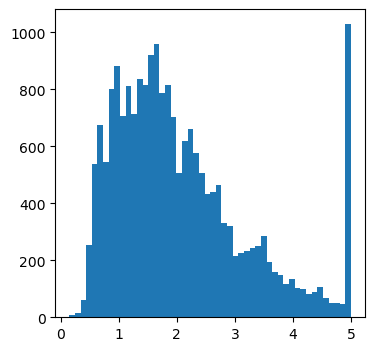

In [97]:
plt.figure(figsize=(4,4))
plt.hist(y, bins=50);

Here is your task:

* Compute the MAE of polynomial basis regression as a function of the degree of the monomials for the Boston housing dataset.  Start with degree equal to 1, i.e. using the features as-is, and compute the error for monomials with degrees 1 to 6.  In each case compute error for both the training set, and a separate test set.  Report the results as a nicely formatted table and comment on what you observe:  is there overfitting or underfitting?  We recommend using the scikit-learn [PolynomialFeatures](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html) functionality in conjunction with the [pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) class as shown in class.  Standardize the data for this task by including standardization as part of the pipeline.  Standardization should be performed before computing the monomials.
* For degree four monomials your model should exhibit overfitting.  Our next step is to see whether we can improve the results by employing regularized linear regression, ie. ridge regression.  Plot the error of ridge regression using degree four monomial data as a function of the regularization parameter $\alpha$ for both the training set and test set.  Is there a value of $\alpha$ for which you are able to obtain test set error that is similar or better than the error of linear regression on the original data?  Comment on your plot, and describe where you are observing overfitting and underfitting.
* As a baseline, compute the error of a naive regression method that for a given regression problem always returns the mean label value.  Compare this error with the error you got using the best performing model and comment on the result.


/opt/miniconda3/envs/myenv/lib/python3.12/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=8.52138e-22): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/opt/miniconda3/envs/myenv/lib/python3.12/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=8.52138e-21): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/opt/miniconda3/envs/myenv/lib/python3.12/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=8.52138e-20): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/opt/miniconda3/envs/myenv/lib/python3.12/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=8.52138e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/opt/miniconda3/envs/myenv/lib/python3.12/site-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.94529e-18): result may 

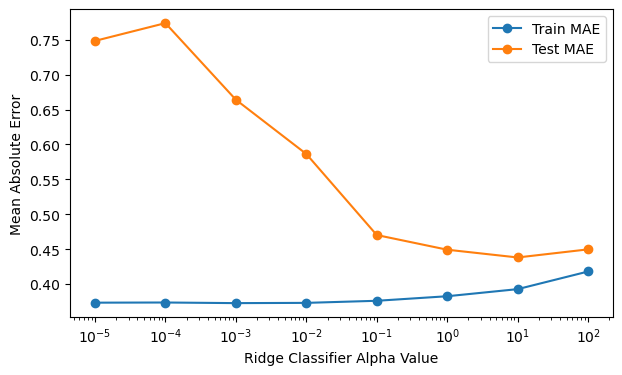



Naive Regression Train MAE: 0.9154234428922327
Naive Regression Test MAE: 0.9080611802926506




,Polynomial Features,Train MAE,Test MAE
0,1,0.530883,0.535248
1,2,0.459473,0.463046
2,3,0.414869,0.442249
3,4,0.372463,0.603657
4,5,0.335876,3.492825
5,6,0.357363,15.703332


In [98]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 1)

# polynomial feaures
results = []
for pf in range(1, 7):
    model = make_pipeline(StandardScaler(), PolynomialFeatures(pf), LinearRegression())
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    results.append([pf, mae(y_train, y_train_pred), mae(y_test, y_test_pred)])

# ridge regression
alphas = [.00001, .0001, .001, .01, .1, 1, 10, 100]
train_errors = []
test_errors = []
for alpha in alphas:
    model = make_pipeline(StandardScaler(), PolynomialFeatures(4), Ridge(alpha = alpha))
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    train_errors.append(mae(y_train, y_train_pred))
    test_errors.append(mae(y_test, y_test_pred))

# naive
naive_train_mae, naive_test_mae = naive_regression(y_train, y_test)

# graph
plt.figure(figsize = (7, 4))
plt.plot(alphas, train_errors, label = "Train MAE", marker = 'o')
plt.plot(alphas, test_errors, label = "Test MAE", marker = 'o')
plt.xscale("log")
plt.ylabel("Mean Absolute Error")
plt.xlabel("Ridge Classifier Alpha Value")
plt.legend()
plt.show()

# baseline error
print("\n")
print(f"Naive Regression Train MAE: {naive_train_mae}")
print(f"Naive Regression Test MAE: {naive_test_mae}")
print("\n")

# table
pd.DataFrame(results, columns = ["Polynomial Features", "Train MAE", "Test MAE"])


**For the table concerning the quantity of polynomial features, there are clear instances of both underfitting and overfitting. When there is 1 or 2 polynomial feautures, the MAE for the training and testing sets are both high, above .45, while also being very close to eachother, meaning the model is underfitting. On the contrary, when there are 4 polynomial features or more, the MAE for the test set drastically increases, creating space between the error values, and thus overfitting the model.**

**When comparing to the naive regression test, all of the alpha values for the ridge classified test set were able to have a lower MAE value than that of the naive regression test set at ~.908. This lets us know that the ridge classifier is performing better, in comparison, at all alpha values. This plot also provides insight as to how much better the ridge classifier is performing than the naive regression. For all alpha values leading up to and including 10<sup>-2</sup>, the test set MAE is extremely high while the train MAE is as low as possible, showing overfitting. The opposite of this is seen for alpha values including and above 10<sup>0</sup>, with both MAE values growing close to eachother, showing underfitting. This leaves us with the alpha value of 10<sup>-1</sup> being the best.**

**As previously mentioned, the best performing models were that that had 4 polynomial features, and the model with an alpha value of .1. These train and test MAE values of ~.372 and ~.604, along with ~.35 and ~.48, respectively, are drastically different than that of the naive baseline. The naive train MAE of ~.915 and test MAE of ~.908 are far worse than the model with polynomial features and the model with the set alpha value.**

## Part 3: Extra credit: Sinusoidal regression

In this section, you will apply sinusoidal regression to model a time-dependent dataset using sinusoidal basis functions. This technique is especially well-suited for modeling periodic or cyclic patterns in data, and can be viewed as a special case of basis-function regression where the features capture oscillatory behavior instead of being standard polynomials.

A sine curve is one of the most fundamental periodic functions in mathematics, described by:

$$
y = A \sin(Bx + C) + D
$$

where:
- $A$ is the amplitude (height of the peaks),
- $B$ is the frequency (related to how many cycles occur per unit of $x$),
- $C$ is the phase shift (horizontal shift),
- $D$ is the vertical offset (baseline around which the curve oscillates).

Sine and cosine functions naturally arise in systems that exhibit periodicity, such as seasonal patterns, acoustics, and planetary motion.

To model complex periodic behaviors, we can construct a sinusoidal basis by combining multiple sine and cosine waves of different frequencies. This approach is closely related to Fourier analysis, where a function is expressed as a sum of sinusoidal components. The general form of a sinusoidal basis function is:

$$
\phi_k(x) = \sin\left(\frac{2\pi k x}{T}\right), \quad k = 1, 2, \dots, M
$$

where:
- $k$ indexes the frequency multiplier (the $k$-th harmonic),
- $T$ is the period of the fundamental oscillation,
- $x$ is the input variable,
- $M$ is the number of sinusoidal terms (i.e., basis size).

By combining multiple $\phi_k(x)$ functions, we can approximate a wide variety of periodic patterns in data. This concept aligns with the Fourier series, where any sufficiently smooth periodic function can be expressed as a linear combination of sine and cosine terms.

A practical example of periodic phenomenon is the sunspot cycle, which refers to the semi-regular rise and fall in the number of sunspots observed on the surface of the Sun. This cycle exhibits an approximate period of 11 years (or about 132 months). In this extra credit assignment, we will use monthly sunspot data stretching back to 1749 to build and test a sinusoidal regression model.

The dataset is to be downloaded from: https://www.sidc.be/SILSO/datafiles#total  
Under the **Total sunspot number** section, download the CSV file titled: **"Monthly mean total sunspot number [1/1749 - now]"**  
Rename the file to `sunspots.csv` and place it in the same directory as your notebook.

Your tasks are as follows:

1. Visualize the data
   - Load the dataset from the `sunspots.csv` file.
   - Plot the number of sunspots as a function of time (in months since January 1749).

2. Construct the feature matrix
   - Use $M = 10$ sinusoidal basis functions:
     $$
     \left\{ \sin\left(\frac{2\pi k x}{T}\right) \mid k = 1, 2, \dots, 10 \right\}
     $$
     where $T = 132$ months (the approximate period of the solar cycle).

   - Split the data into:
     - Training set: first 80% of observations
     - Test set: remaining 20%

     (for time series data, the convention is to perform chronological split rather than random split)

   - Standardize the features before performing regression.

3. Ridge regression
   - Train a ridge regression model to predict sunspot numbers from the sinusoidal basis features.
   - Test different regularization values:
     $\alpha \in \{0.01, 0.1, 1, 10, 100\}$
   - Compute the Mean Absolute Error (MAE) for both training and test sets for each value of $\alpha$.
   - Plot the MAE as a function of $\alpha$.

4. Visualize predictions
   - Plot the original sunspot data.
   - Overlay the predictions from your model on the test set.
   - Use appropriate legend and color schemes to clearly distinguish between real and predicted values.

This is an extra credit assignment graded on the quality of approach and depth of analysis. There are many ways to approach this problem, and all reasonable and potentially useful solutions will be awarded the extra credit.
You are encouraged to:
- Make thoughtful choices about feature scaling, regularization, and plotting.
- Discuss your findings and the model limitations.
- Experiment beyond the minimum requirements if you find interesting extensions.

### Resources

**Introduction to Time-Series Data**   
    https://towardsdatascience.com/time-series-from-scratch-train-test-splits-and-evaluation-metrics-4fd654de1b37/   
    https://wandb.ai/iamleonie/A-Gentle-Introduction-to-Time-Series-Analysis-Forecasting/reports/A-gentle-introduction-to-time-series-analysis-forecasting--VmlldzoxMDg5NDMxMw
    
**Modeling Real-World Data with Sinusoidal Functions**  
    https://mtimpa.weebly.com/uploads/1/9/3/5/19359645/chap06.2.pdf

**Sinusoidal Regression Tutorials**    
  https://www.geeksforgeeks.org/data-analysis/fitting-a-sine-curve-to-data-with-pylab-and-numpy/   
  https://medium.com/data-science/how-to-predict-a-variable-sinusoid-in-python-4a21404dc061    

**Bayesian Ridge Regression**    
  https://scikit-learn.org/stable/auto_examples/linear_model/plot_bayesian_ridge_curvefit.html

**MIT OpenCourseWare: Introduction to Fourier Series**    
  https://ocw.mit.edu/courses/18-03-differential-equations-spring-2010/resources/lecture-15-introduction-to-fourier-series


Use of these resources are optional, and you are welcome to use other resources (provided you reference them in Part 4)

### Part 4:  Use of AI and web resources

In the cell below indicate in detail how you used AI and other web resources for this assignment.  If you used AI tools, indicate how useful they were.

**As for AI use in this assignment, I barely used it since I was able to get so much information from the notebooks that we go over in class. When using AI for school assignments, I really only use it to reword instructions or for the occasional code help. Although I do sometimes utilize AI, I made a strong point to ensure that I am not relying on it at any point of my process and that I am able to walk away from the assignment confident in what I have learned, whether I used AI to help or not.**

### Your Report

Answer the questions in the cells reserved for that purpose.

### Submission

Submit your report as a Jupyter notebook via Canvas.  Running the notebook should generate all the plots in your notebook.

### Grading 


```
Grading sheet for assignment 4

Part 1:  50 points.
Dataset creation:  all the features were correctly converted to 
numerical values and the BMI and age values were standardized (15 pts)
Evaluation of linear regression (15 pts)
Feature selection based on weight vector magnitude, including discussion of the choice of features (15 pts)
Comparison to the basline model and explanation why it is important (5 pts)

Part 2:  50 points.
Train/test accuracy as a function of the degree of polynomial 
regression and discussion of results (20 pts)
Successful application of ridge regression to prevent overfitting and discussion of results (25 pts)
Comparison to the basline model (5 pts)
```

Grading will be based on the following criteria:

  * Code correctness.
  * Code is well organized.
  * Plots and other results are well formatted and easy to understand.
  * Interesting and meaningful observations made where requested.